In [1]:
import numpy as np
import time
import warnings

warnings.filterwarnings("ignore", category=np.ComplexWarning)
np.set_printoptions(formatter={'float': '{: .10e}'.format}, linewidth=1000)

## 1. HE Environment Setup

In [2]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import engine.HEdata
import engine.HEengine

importlib.reload(engine.HEdata)
importlib.reload(engine.HEengine)

from engine.HEengine import HEengine
from engine.HEdata import Message, Ciphertext

import os

# HE_DEVICE=cpu / HE_SETTING_ROOT=... to run on a HEaaN-CPU environment.
engine = HEengine(
    device_type=os.environ.get("HE_DEVICE", "gpu"),
    setting_root=os.environ.get("HE_SETTING_ROOT", "/root/heaan_setting/"),
)

## 2. Approx invSqrt using Chebyshev Polynomial

In [3]:
def genData(start, middle, end, n):
    a = np.linspace(start, middle, n//2)
    b = np.linspace(middle, end, n//2)
    return np.concatenate((a, b))

In [4]:
def ret_print(x, y, y_eval):
    print("Input\t\t:", x)
    print("Answer\t\t:", y)
    print("Eval ret\t:", y_eval)

    err = y - y_eval
    mre = np.mean(np.abs(err) / np.abs(y))

    print("MRE\t\t:", mre)

--- 63차 체비쇼프 근사 다항식 계수 ---


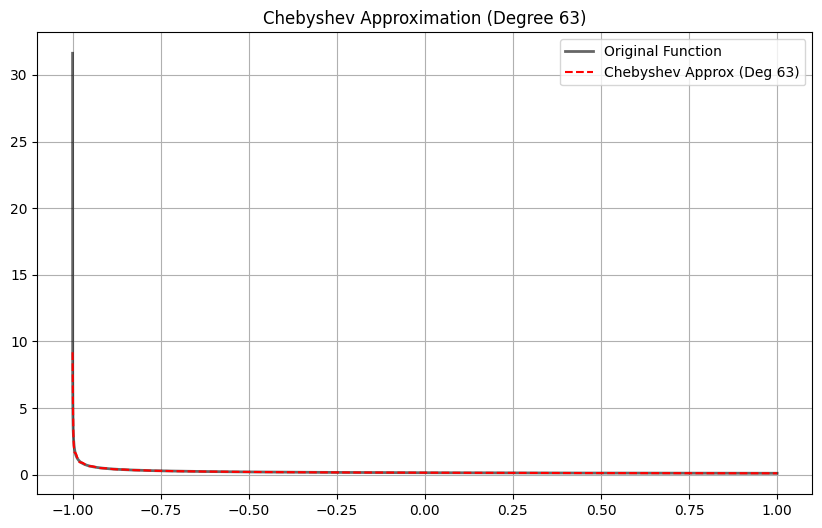


최대 오차 (Max Error): 7.10e-01


(array([-1.0000000000e+00, -9.9999800000e-01, -9.9999600000e-01, ...,  9.9999600000e-01,  9.9999800000e-01,  1.0000000000e+00]),
 array([ 3.1622776602e+01,  3.0151146792e+01,  2.8867535110e+01, ...,  1.0000010000e-01,  1.0000005000e-01,  1.0000000000e-01]),
 array([ 9.1788882560e+00,  9.1696570695e+00,  9.1604353679e+00, ...,  9.9276031290e-02,  9.9269976578e-02,  9.9263905442e-02]),
 array([], dtype=float64))

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

def get_chebyshev_approximation(target_func, degree, domain):
    approx_poly = Chebyshev.interpolate(target_func, degree, domain=domain)
    return approx_poly

K = 2 # inverse of K-th root
DOMAIN = [-1, 1]

# 1. 설정
log_deg = 6
degree = 2**log_deg-1

A = 1e-3  # INV_SQRT_V_MIN (operators/HEhypo_test.py)
B = 1 * (10 ** 2)

def func(h):
    result = []
    for x in h:
        x = (B-A)*x/2+(B+A)/2
        result.append(pow(x, -1/K))
    return np.array(result)    

# 3. 근사 다항식 생성
cheb_poly = get_chebyshev_approximation(func, degree, DOMAIN)

# 4. 결과 확인 (다항식 계수 출력)
print(f"--- {degree}차 체비쇼프 근사 다항식 계수 ---") 

# 5. 시각화 (원본 vs 근사)
x_vals = np.linspace(DOMAIN[0], DOMAIN[1], 1000000)
y_true = func(x_vals)
y_approx = cheb_poly(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_true, 'k-', label='Original Function', linewidth=2, alpha=0.6)
plt.plot(x_vals, y_approx, 'r--', label=f'Chebyshev Approx (Deg {degree})')

plt.title(f"Chebyshev Approximation (Degree {degree})")
plt.legend()
plt.grid(True)
plt.show()

# 6. 오차 확인
error = np.abs(y_true - y_approx) / y_true
print(f"\n최대 오차 (Max Error): {np.max(error):.2e}")
x_vals, y_true, y_approx, y_approx[y_approx<0]

In [6]:
x = np.concatenate([np.linspace(A, (A+B)/2, 10000000), np.linspace((A+B)/2, B, 10000000)])
y_ans = x**(-1/2)

print(f"X\n{x}\n")

trans_x = x*2/(B-A) - (B+A)/(B-A)
cheb_y = cheb_poly(trans_x)
print("First Approx")
print(cheb_y)
print("#Neg\t\t:", len(cheb_y[cheb_y < 0]))
print()

iter = 10
y_iter = np.copy(cheb_y)

for i in range(iter):
    print("#", i+1)
    y_iter = (3/2) * y_iter - (1/2)*x*(y_iter**3)
    ret_print(x, y_ans, y_iter)
    print("Max RE\t\t:", np.max(np.abs((y_ans-y_iter)/y_ans)), f"({np.argmax(np.abs((y_ans-y_iter)/y_ans))})")
    print()

X
[ 1.0000000000e-03  1.0049999505e-03  1.0099999010e-03 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]



First Approx
[ 9.1788882560e+00  9.1784264717e+00  9.1779647111e+00 ...  9.9264513295e-02  9.9264209389e-02  9.9263905442e-02]
#Neg		: 0

# 1


Input		: [ 1.0000000000e-03  1.0049999505e-03  1.0099999010e-03 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 3.1622776602e+01  3.1544015671e+01  3.1465840319e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 1.3381662585e+01  1.3379095227e+01  1.3376528479e+01 ...  9.9991910673e-02  9.9991901545e-02  9.9991892414e-02]
MRE		: 0.00034156588552072944


Max RE		: 0.576834673516367 (0)

# 2
Input		: [ 1.0000000000e-03  1.0049999505e-03  1.0099999010e-03 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 3.1622776602e+01  3.1544015671e+01  3.1465840319e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 1.8874374121e+01  1.8865225460e+01  1.8856084177e+01 ...  1.0000000402e-01  1.0000000152e-01  9.9999999014e-02]


MRE		: 1.716370271674757e-05


...

Max RE		: 4.916275143640809e-16 (6971901)

# 9
Input		: [ 1.0000000000e-03  1.0049999505e-03  1.0099999010e-03 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 3.1622776602e+01  3.1544015671e+01  3.1465840319e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 3.1622776602e+01  3.1544015671e+01  3.1465840319e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]


MRE		: 8.747290183943201e-17


Max RE		: 4.916494435855603e-16 (6972523)

# 10
Input		: [ 1.0000000000e-03  1.0049999505e-03  1.0099999010e-03 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 3.1622776602e+01  3.1544015671e+01  3.1465840319e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 3.1622776602e+01  3.1544015671e+01  3.1465840319e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]


MRE		: 8.750952511818232e-17


Max RE		: 4.916275143640809e-16 (6971901)



## 3. Test invSqrt using HEengine

In [7]:
data_num = 100_000
test = genData(A, (A+B)/2, B, data_num)

msg = Message(test, value=B)

if engine.is_gpu():
    msg.to(engine.dt)

ctxt = engine.enc(msg)

x_half = engine.mult(ctxt, 1/2)

x_cheb = engine.mult(ctxt, 2/(B-A))
x_cheb = engine.sub(x_cheb, (B+A)/(B-A))

In [8]:
import importlib

import operators.HEapprox

importlib.reload(operators.HEapprox)

from operators.HEapprox import HEApprox

stats = HEApprox(engine)

In [9]:
start = time.time()

ret_ctxt = stats.invSqrt(x_half, x_cheb, domain=(A, B), log_degree=log_deg, iteration=10)

end = time.time()

ret_msg = engine.dec(ret_ctxt)

ret = np.concatenate([
    np.array(ret_msg[i], dtype=np.float64)
    for i in range(len(ret_msg))
])

# Remove padded slots.
ret = ret[:data_num]

ans = test ** (-0.5)
abs_error = np.abs(ans - ret)
rel_error = abs_error / np.abs(ans)

max_idx = np.argmax(rel_error)

print("Max RE\t\t:", rel_error[max_idx], f"({max_idx})")
print("\t\t", ret[max_idx], ans[max_idx])
print("Max AE\t\t:", np.max(abs_error))
print("Mean RE\t\t:", np.mean(rel_error))
print("Time\t\t:", end - start)

Max RE		: 1.237996227885619e-05 (0)
		 31.623168090465278 31.622776601683796
Max AE		: 0.00039148878148154154
Mean RE		: 5.4380726656041514e-09
Time		: 66.5328414440155


## 4. Approx TCrit using Chebyshev Polynomial

In [34]:
# Settings
alpha = 0.025
df_min, df_max = 1.0, 2000.0
u_min, u_max = 1.0 / df_max, 1.0 / df_min

log_degree = 4
degree = 2 ** log_degree - 1

# Target function
def target_func(z):

    u = (u_max - u_min) * z / 2.0 + (u_max + u_min) / 2.0
    df = 1.0 / u
    critical = stats.t.ppf(1.0 - alpha / 2.0, df)

    return critical ** 2

# Chebyshev approximation
cheb_poly = Chebyshev.interpolate(target_func, degree, domain=[-1.0, 1.0])

# Evaluation
u = np.linspace(u_min, u_max, 100_000, dtype=np.float64)
df = 1.0 / u
z = 2.0 * (u - u_min) / (u_max - u_min) - 1.0

y_true = stats.t.ppf(1.0 - alpha / 2.0, df) ** 2
y_approx = cheb_poly(z)

abs_error = np.abs(y_true - y_approx)
rel_error = abs_error / np.abs(y_true)

print("degree        :", degree)
print("max abs error :", np.max(abs_error))
print("max rel error :", np.max(rel_error))
print("mean abs error:", np.mean(abs_error))

degree        : 15
max abs error : 3.9512443095190974e-06
max rel error : 9.773931109222427e-09
mean abs error: 1.1997284271715537e-07


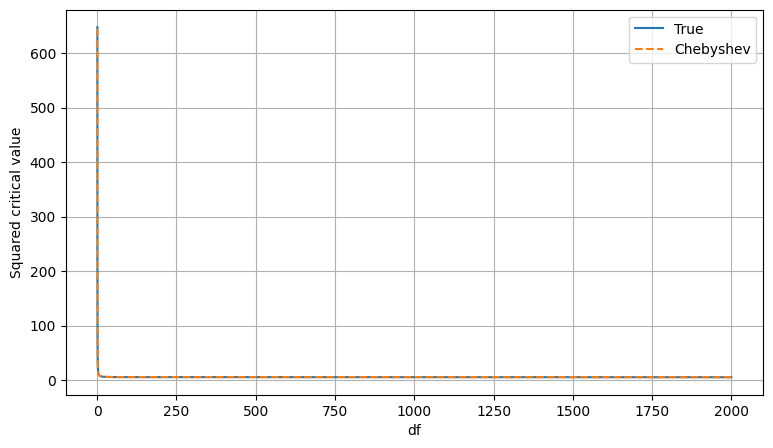

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(df, y_true, label="True")
plt.plot(df, y_approx, "--", label="Chebyshev")
plt.xlabel("df")
plt.ylabel("Squared critical value")
plt.legend()
plt.grid(True)
plt.show()

## 4-1. Squared t critical-value coefficients on InvDF in [1/2000, 1]

`HEHypothesisTesting` maps InvDF = 1/df from [1/2000, 1] (df in [1, 2000]) to [-1, 1] and evaluates
P(u) ~ t_{1-alpha/2, 1/u}^2 (`_T_CRITICAL_SQ_COEFFS`) for degrees 2^3-1, ..., 2^7-1 and the supported alpha values.
Saved to `coeffs/t_critical_coeffs.py`.

In [2]:
from pathlib import Path
from numpy.polynomial import Chebyshev
from scipy import stats as sp_stats

T_ALPHA_LIST = [0.001, 0.01, 0.025, 0.05, 0.1]  # two-sided
T_LOG_DEG_LIST = range(3, 8)                    # degree = 2^3-1, ..., 2^7-1
T_U_MIN, T_U_MAX = 1.0 / 2000.0, 1.0

def make_t_sq_target(alpha):
    def f(z):
        u = (T_U_MAX - T_U_MIN) * z / 2.0 + (T_U_MAX + T_U_MIN) / 2.0
        return sp_stats.t.ppf(1.0 - alpha / 2.0, 1.0 / u) ** 2
    return f

# t_sq_polys[degree][alpha]
t_sq_polys = {
    2**ld-1: {
        alpha: Chebyshev.interpolate(make_t_sq_target(alpha), 2**ld-1, domain=[-1.0, 1.0])
        for alpha in T_ALPHA_LIST
    }
    for ld in T_LOG_DEG_LIST
}

df_grid = np.unique(np.concatenate([np.geomspace(1.0, 2000.0, 20001), np.arange(1.0, 2001.0)]))
z_grid = 2.0 * (1.0 / df_grid - T_U_MIN) / (T_U_MAX - T_U_MIN) - 1.0
DF_BANDS = [(1, 2), (2, 10), (10, 30), (30, 2000)]

print("degree\talpha\tMaxAE\t\tMaxRE\t\tMRE\t\tMaxRE by df band " + str(DF_BANDS))

for deg, by_alpha in t_sq_polys.items():
    for alpha, poly in by_alpha.items():
        y_true = sp_stats.t.ppf(1.0 - alpha / 2.0, df_grid) ** 2
        err = np.abs(poly(z_grid) - y_true)
        re = err / y_true
        bands = [np.max(re[(df_grid >= lo) & (df_grid <= hi)]) for lo, hi in DF_BANDS]
        print(f"{deg}\t{alpha}\t{np.max(err):.2e}\t{np.max(re):.2e}\t{np.mean(re):.2e}\t"
              + " ".join(f"{b:.2e}" for b in bands))

t_coeff_path = Path("t_critical_coeffs.py")

lines = [
    "# Generated by coeffs/approx.ipynb (section 4-1)",
    "# Chebyshev coefficients of the squared two-sided t critical value t_{1-alpha/2, df}^2",
    "# as a function of InvDF = 1/df in [_T_CRITICAL_U_MIN, _T_CRITICAL_U_MAX], mapped to [-1, 1].",
    f"_T_CRITICAL_U_MIN = {T_U_MIN!r}",
    f"_T_CRITICAL_U_MAX = {T_U_MAX!r}",
    "",
    "_T_CRITICAL_SQ_COEFFS = {",
]

for deg, by_alpha in t_sq_polys.items():
    lines.append(f"    {deg}: {{")
    for alpha, poly in by_alpha.items():
        coeffs = ", ".join(repr(value) for value in poly.coef.astype(float).tolist())
        lines.append(f"        {alpha!r}: [{coeffs}],")
    lines.append("    },")

lines.append("}")
lines.append("")

_ = t_coeff_path.write_text("\n".join(lines), encoding="utf-8")
print(t_coeff_path.resolve())

degree	alpha	MaxAE		MaxRE		MRE		MaxRE by df band [(1, 2), (2, 10), (10, 30), (30, 2000)]
7	0.001	1.96e+03	4.78e+01	2.33e+01	8.47e-01 2.03e+01 3.93e+01 4.78e+01
7	0.01	2.49e+00	1.51e-01	7.89e-02	1.48e-02 9.00e-02 1.34e-01 1.51e-01
7	0.025	1.07e-01	1.03e-02	5.55e-03	1.83e-03 6.91e-03 9.33e-03 1.03e-02
7	0.05	7.05e-03	1.01e-03	5.64e-04	2.73e-04 7.42e-04 9.38e-04 1.01e-03
7	0.1	2.87e-04	6.70e-05	3.86e-05	2.61e-05 5.31e-05 6.33e-05 6.70e-05


15	0.001	2.20e-02	9.36e-04	4.18e-04	1.39e-05 3.70e-04 7.57e-04 9.36e-04
15	0.01	1.43e-05	1.37e-07	6.62e-08	1.27e-08 7.85e-08 1.20e-07 1.37e-07
15	0.025	3.95e-06	9.77e-09	8.75e-10	9.77e-09 5.04e-09 1.17e-09 6.71e-09
15	0.05	5.89e-08	9.29e-09	1.15e-09	9.82e-11 9.29e-09 3.57e-09 5.53e-09
15	0.1	3.35e-08	1.09e-08	5.76e-10	1.65e-10 7.33e-09 1.09e-08 1.04e-08
31	0.001	1.54e-03	3.01e-08	1.21e-08	9.56e-09 1.71e-08 2.55e-08 3.01e-08


31	0.01	1.54e-05	1.55e-08	6.37e-09	9.74e-09 9.80e-09 1.32e-08 1.55e-08
31	0.025	3.56e-06	9.81e-09	2.97e-09	8.47e-09 7.12e-09 6.05e-09 9.81e-09
31	0.05	3.69e-08	8.34e-09	3.95e-10	1.86e-11 5.82e-09 2.37e-10 8.34e-09
31	0.1	4.23e-08	1.47e-08	7.98e-10	6.81e-11 8.22e-09 1.47e-08 1.42e-08
63	0.001	2.56e-03	3.82e-07	1.73e-07	8.57e-09 2.13e-07 3.14e-07 3.82e-07
63	0.01	1.44e-05	1.25e-08	3.48e-09	5.18e-09 8.49e-09 6.37e-09 1.25e-08


63	0.025	4.29e-06	1.03e-08	1.92e-09	9.76e-09 1.03e-08 3.84e-09 9.49e-09
63	0.05	4.26e-08	9.94e-09	6.02e-10	2.70e-11 6.73e-09 1.75e-09 9.94e-09
63	0.1	4.28e-08	9.70e-09	4.85e-10	9.59e-11 9.38e-09 9.70e-09 9.26e-09
127	0.001	2.26e-03	1.04e-07	4.72e-08	9.21e-09 5.55e-08 8.70e-08 1.04e-07
127	0.01	1.08e-05	1.11e-08	2.64e-09	5.94e-09 6.73e-09 5.34e-09 1.11e-08
127	0.025	2.27e-06	9.62e-09	6.16e-10	7.27e-09 8.70e-09 1.33e-09 9.62e-09


127	0.05	5.31e-08	8.38e-09	2.00e-10	1.40e-11 8.38e-09 6.54e-10 5.13e-09
127	0.1	4.18e-08	1.46e-08	4.63e-10	2.98e-11 6.96e-09 6.17e-09 1.46e-08
/pp_test/coeffs/t_critical_coeffs.py


## 5. Sign approximation (HEApprox.sign) check

Composite polynomial `coeffs/sign_coeffs.py` (StepHE, input in [-1, 1]).
Plaintext: error |P(x) - sign(x)| by |x| range and the valid range. HE: `HEApprox.sign` on a fresh
level-12 ciphertext, `SIGN_REPS` repetitions (time, bootstraps, output level, error by |x| range).

In [3]:
import matplotlib.pyplot as plt
from numpy.polynomial import chebyshev as np_cheb
from coeffs.sign_coeffs import _SIGN_PPTEST_DATA

sign_degrees = [len(c) - 1 for c in _SIGN_PPTEST_DATA]
print("stages:", len(sign_degrees), "degrees:", sign_degrees,
      "total depth:", sum(int(np.ceil(np.log2(d + 1))) for d in sign_degrees))

def sign_plain(x, return_stages=False):
    y, stages = np.asarray(x, dtype=np.float64), []
    for c in _SIGN_PPTEST_DATA:
        y = np_cheb.chebval(y, c)
        stages.append(y)
    return (y, stages) if return_stages else y

SIGN_BINS = [(10.0**-(k+1), 10.0**-k) for k in range(7)]  # [1e-1, 1), ..., [1e-7, 1e-6)

def sign_bin_errors(x, y):
    err = np.abs(y - np.sign(x))
    return {lo: float(np.max(err[(np.abs(x) >= lo) & (np.abs(x) < hi)])) for lo, hi in SIGN_BINS}

x_plain = np.concatenate([np.geomspace(1e-7, 1.0, 400001), -np.geomspace(1e-7, 1.0, 400001)])
y_plain, stages = sign_plain(x_plain, return_stages=True)

print("\nplaintext max |P(x) - sign(x)| by |x| range")
for lo, e in sign_bin_errors(x_plain, y_plain).items():
    print(f"  |x| in [{lo:.0e}, {lo*10:.0e}) : {e:.2e}")

print("\nmax |stage output| (regular bootstrap needs [-1, 1]):",
      [f"{np.max(np.abs(s)):.6f}" for s in stages])
print("first stage at x = 1:", np_cheb.chebval(1.0, _SIGN_PPTEST_DATA[0]))

stages: 8 degrees: [7, 7, 15, 15, 15, 15, 31, 31] total depth: 32



plaintext max |P(x) - sign(x)| by |x| range
  |x| in [1e-01, 1e+00) : 1.25e-09
  |x| in [1e-02, 1e-01) : 1.24e-09
  |x| in [1e-03, 1e-02) : 1.24e-09
  |x| in [1e-04, 1e-03) : 1.24e-09
  |x| in [1e-05, 1e-04) : 1.24e-09
  |x| in [1e-06, 1e-05) : 1.24e-09
  |x| in [1e-07, 1e-06) : 8.20e-10

max |stage output| (regular bootstrap needs [-1, 1]): ['1.000000', '1.000000', '1.000000', '1.000000', '1.000000', '1.000000', '1.000336', '1.000000']
first stage at x = 1: 1.7673630781089855e-07


In [4]:
import importlib
import operators.HEapprox
importlib.reload(operators.HEapprox)
from operators.HEapprox import HEApprox

approx = HEApprox(engine)

SIGN_REPS = 10

half = engine.num_slots // 2
x_sign = np.concatenate([np.geomspace(1e-7, 1.0, half), -np.geomspace(1e-7, 1.0, half)])

sign_runs = []

for rep in range(SIGN_REPS):
    ctxt = engine.enc(Message(x_sign, engine.log_slots), level=12)

    approx.reset_bootstrap_count()
    start = time.perf_counter()
    ret_ctxt = approx.sign(ctxt)
    elapsed = time.perf_counter() - start

    y_he = np.array(engine.dec(ret_ctxt)[0], dtype=np.complex128).real[:len(x_sign)]
    sign_runs.append({
        "time": elapsed,
        "bootstraps": approx.bootstrap_count(),
        "level": ret_ctxt.level(),
        "bins": sign_bin_errors(x_sign, y_he),
        "y": y_he,
    })

times = np.array([r["time"] for r in sign_runs])
print(f"time\t\t: {times.mean():.3f} +- {times.std(ddof=1):.3f} s ({SIGN_REPS} reps)")
print(f"bootstraps\t: {sorted(set(r['bootstraps'] for r in sign_runs))}")
print(f"output level\t: {sorted(set(r['level'] for r in sign_runs))}")

y_plain_he_input = sign_plain(x_sign)
print("\nmax |HE - sign(x)| (max over reps) | max |HE - plaintext P(x)| by |x| range")
for lo, hi in SIGN_BINS:
    mask = (np.abs(x_sign) >= lo) & (np.abs(x_sign) < hi)
    e_sign = max(r["bins"][lo] for r in sign_runs)
    e_plain = max(float(np.max(np.abs(r["y"][mask] - y_plain_he_input[mask]))) for r in sign_runs)
    print(f"  |x| in [{lo:.0e}, {hi:.0e}) : {e_sign:.2e} | {e_plain:.2e}")

near_one = np.abs(x_sign) > 0.99
print(f"\n|x| > 0.99: max |HE - sign(x)| = {max(np.max(np.abs(r['y'][near_one] - np.sign(x_sign[near_one]))) for r in sign_runs):.2e}")
wrong = [int(np.sum(np.sign(r["y"]) != np.sign(x_sign))) for r in sign_runs]
print(f"wrong-sign slots per rep: {wrong}")

time		: 10.504 +- 0.613 s (10 reps)
bootstraps	: [4]
output level	: [7]

max |HE - sign(x)| (max over reps) | max |HE - plaintext P(x)| by |x| range
  |x| in [1e-01, 1e+00) : 5.50e-09 | 5.90e-09
  |x| in [1e-02, 1e-01) : 7.37e-09 | 6.93e-09
  |x| in [1e-03, 1e-02) : 5.30e-09 | 6.06e-09
  |x| in [1e-04, 1e-03) : 6.06e-09 | 5.57e-09
  |x| in [1e-05, 1e-04) : 7.53e-09 | 8.00e-09
  |x| in [1e-06, 1e-05) : 6.79e-09 | 6.04e-09
  |x| in [1e-07, 1e-06) : 2.00e+00 | 2.00e+00

|x| > 0.99: max |HE - sign(x)| = 2.00e+00
wrong-sign slots per rep: [0, 1, 1, 2, 1, 1, 1, 0, 0, 0]


In [5]:
# Edges of the valid input range in HE: |x| near 1 (first stage vanishes at x = 1)
# and |x| near 0 (CKKS noise), SIGN_REPS repetitions.
q = engine.num_slots // 4
x_hi = np.linspace(0.95, 1.0, q)
x_lo = np.geomspace(1e-8, 1e-5, q)
x_edge = np.concatenate([x_hi, -x_hi, x_lo, -x_lo])

print("first stage near 1:", {v: round(float(np_cheb.chebval(v, _SIGN_PPTEST_DATA[0])), 6) for v in [0.95, 0.99, 0.999, 0.9999, 1.0]})

wrong_hi, wrong_lo = [], []

for rep in range(SIGN_REPS):
    ret_ctxt = approx.sign(engine.enc(Message(x_edge, engine.log_slots), level=12))
    y_edge = np.array(engine.dec(ret_ctxt)[0], dtype=np.complex128).real[:len(x_edge)]
    wrong = np.sign(y_edge) != np.sign(x_edge)
    ax = np.abs(x_edge)
    wrong_hi.extend(ax[wrong & (ax > 0.5)])
    wrong_lo.extend(ax[wrong & (ax < 0.5)])

print(f"wrong-sign |x| in [0.95, 1]  : {len(wrong_hi)} slots over {SIGN_REPS} reps, smallest |x| = {min(wrong_hi) if wrong_hi else None}")
print(f"wrong-sign |x| in [1e-8, 1e-5]: {len(wrong_lo)} slots over {SIGN_REPS} reps, largest |x| = {max(wrong_lo) if wrong_lo else None}")

first stage near 1: {0.95: 0.817549, 0.99: 0.232561, 0.999: 0.025068, 0.9999: 0.002526, 1.0: 0.0}


wrong-sign |x| in [0.95, 1]  : 9 slots over 10 reps, smallest |x| = 1.0
wrong-sign |x| in [1e-8, 1e-5]: 5652 slots over 10 reps, largest |x| = 1.4697949308248822e-07


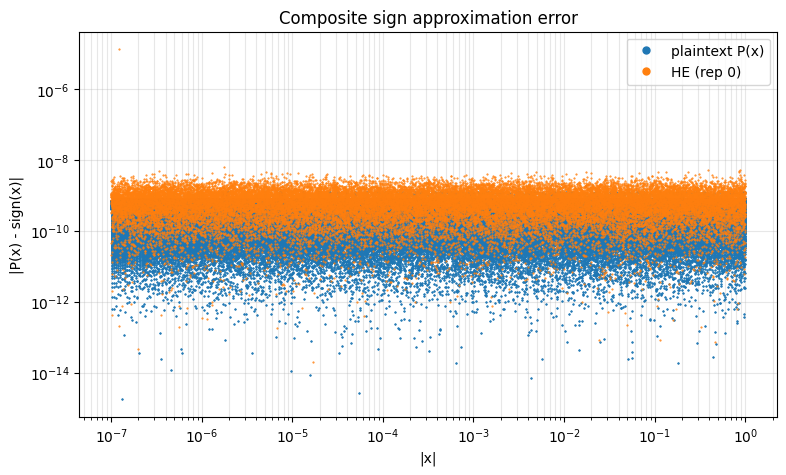

In [6]:
plt.figure(figsize=(9, 5))
plt.loglog(np.abs(x_plain), np.abs(y_plain - np.sign(x_plain)) + 1e-17, ".", ms=1, label="plaintext P(x)")
plt.loglog(np.abs(x_sign), np.abs(sign_runs[0]["y"] - np.sign(x_sign)) + 1e-17, ".", ms=1, label="HE (rep 0)")
plt.xlabel("|x|")
plt.ylabel("|P(x) - sign(x)|")
plt.title("Composite sign approximation error")
plt.legend(markerscale=10)
plt.grid(True, which="both", alpha=0.3)
plt.show()